## Step 1: Import Libraries

In [22]:
import os
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, classification_report, confusion_matrix

## Step 2: Load Dataset

In [23]:
data_path = r'd:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\dataset\f1_strategy_dataset_v4.csv'
df = pd.read_csv(data_path)

print('Dataset shape:', df.shape)
display(df.head())

target_column = 'PitNextLap'
print(df[target_column].value_counts())

Dataset shape: (101371, 16)


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


PitNextLap
0    75542
1    25829
Name: count, dtype: int64


## Step 3: Prepare Data

In [24]:
X = df.drop(columns=[target_column])
y = df[target_column].astype(int)

X = pd.get_dummies(X, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=21,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Class distribution in train:')
print(y_train.value_counts(normalize=True).sort_index())

X_train shape: (81096, 76)
X_test shape: (20275, 76)
Class distribution in train:
PitNextLap
0    0.745203
1    0.254797
Name: proportion, dtype: float64


## Step 4: Train RandomForest Model

In [25]:
model = RandomForestClassifier(
    n_estimators=150,
    random_state=21,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('Model training completed')

Model training completed


## Step 5: Check Model Performance

In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
loss = log_loss(y_test, y_prob)

print('Accuracy:', round(accuracy, 4))
print('Precision:', round(precision, 4))
print('Recall:', round(recall, 4))
print('F1 Score:', round(f1, 4))
print('ROC AUC:', round(roc_auc, 4))
print('Log Loss:', round(loss, 4))

print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

Accuracy: 0.9694
Precision: 0.9729
Recall: 0.905
F1 Score: 0.9377
ROC AUC: 0.9951
Log Loss: 0.1264

Classification Report:

              precision    recall  f1-score   support

           0     0.9683    0.9914    0.9797     15109
           1     0.9729    0.9050    0.9377      5166

    accuracy                         0.9694     20275
   macro avg     0.9706    0.9482    0.9587     20275
weighted avg     0.9695    0.9694    0.9690     20275



## Step 6: Plot Confusion Matrix

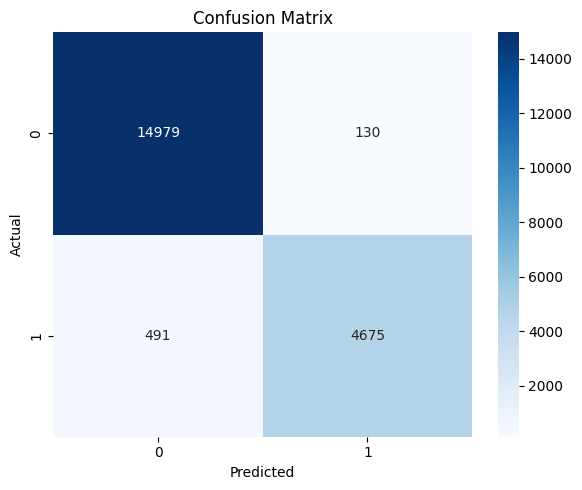

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 7: Save Model and Metrics

In [28]:
base_output = r'd:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\F1_Strategy'
model_dir = os.path.join(base_output, 'model')
metrics_dir = os.path.join(base_output, 'metrics')

os.makedirs(model_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'model.joblib')
columns_path = os.path.join(model_dir, 'feature_columns.json')
labels_path = os.path.join(model_dir, 'label_classes.json')
info_path = os.path.join(model_dir, 'target_info.json')
metrics_path = os.path.join(metrics_dir, 'final_metircs.csv')
predictions_path = os.path.join(metrics_dir, 'prediction.csv')

joblib.dump(model, model_path)
with open(columns_path, 'w', encoding='utf-8') as f:
    json.dump(list(X.columns), f, indent=2)
with open(labels_path, 'w', encoding='utf-8') as f:
    json.dump([0, 1], f, indent=2)
with open(info_path, 'w', encoding='utf-8') as f:
    json.dump({'target_col': target_column, 'model_name': 'RandomForestClassifier'}, f, indent=2)

final_metrics = pd.DataFrame([
    {'metric': 'accuracy', 'value': accuracy},
    {'metric': 'precision', 'value': precision},
    {'metric': 'recall', 'value': recall},
    {'metric': 'f1', 'value': f1},
    {'metric': 'roc_auc', 'value': roc_auc},
    {'metric': 'log_loss', 'value': loss}
])
final_metrics.to_csv(metrics_path, index=False)

prediction_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Probability': y_prob
})
prediction_df.to_csv(predictions_path, index=False)

print('Saved model:', model_path)
print('Saved columns:', columns_path)
print('Saved labels:', labels_path)
print('Saved target info:', info_path)
print('Saved metrics:', metrics_path)
print('Saved predictions:', predictions_path)

Saved model: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\F1_Strategy\model\model.joblib
Saved columns: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\F1_Strategy\model\feature_columns.json
Saved labels: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\F1_Strategy\model\label_classes.json
Saved target info: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\F1_Strategy\model\target_info.json
Saved metrics: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\F1_Strategy\metrics\final_metircs.csv
Saved predictions: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\F1_Strategy\metrics\prediction.csv


## Step 8: Final Summary

In [29]:
summary = pd.DataFrame([
    {'Metric': 'Accuracy', 'Value': accuracy},
    {'Metric': 'Precision', 'Value': precision},
    {'Metric': 'Recall', 'Value': recall},
    {'Metric': 'F1 Score', 'Value': f1},
    {'Metric': 'ROC AUC', 'Value': roc_auc},
    {'Metric': 'Log Loss', 'Value': loss}
])

display(summary)
print('Final model used: RandomForestClassifier')
print('Target column:', target_column)

,Metric,Value
0,Accuracy,0.969371
1,Precision,0.972945
2,Recall,0.904955
3,F1 Score,0.937719
4,ROC AUC,0.995099
5,Log Loss,0.126425


Final model used: RandomForestClassifier
Target column: PitNextLap
